<a href="https://colab.research.google.com/github/GinaLinqinChen/ComputerVision/blob/main/Cantonese_to_Madarin_CV_Asgn1_finalversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 1 of Computer Vision

student ID: 5516729

student name: CHEN Ruijun

# 1 Use tesseract-ocr to detect Cantonese characters.

1.1 You need to upload the language package ***chi_tra.traineddata*** (link:https://github.com/tesseract-ocr/tessdata).

1.1 你需要先下载繁体中文语言包到本地。

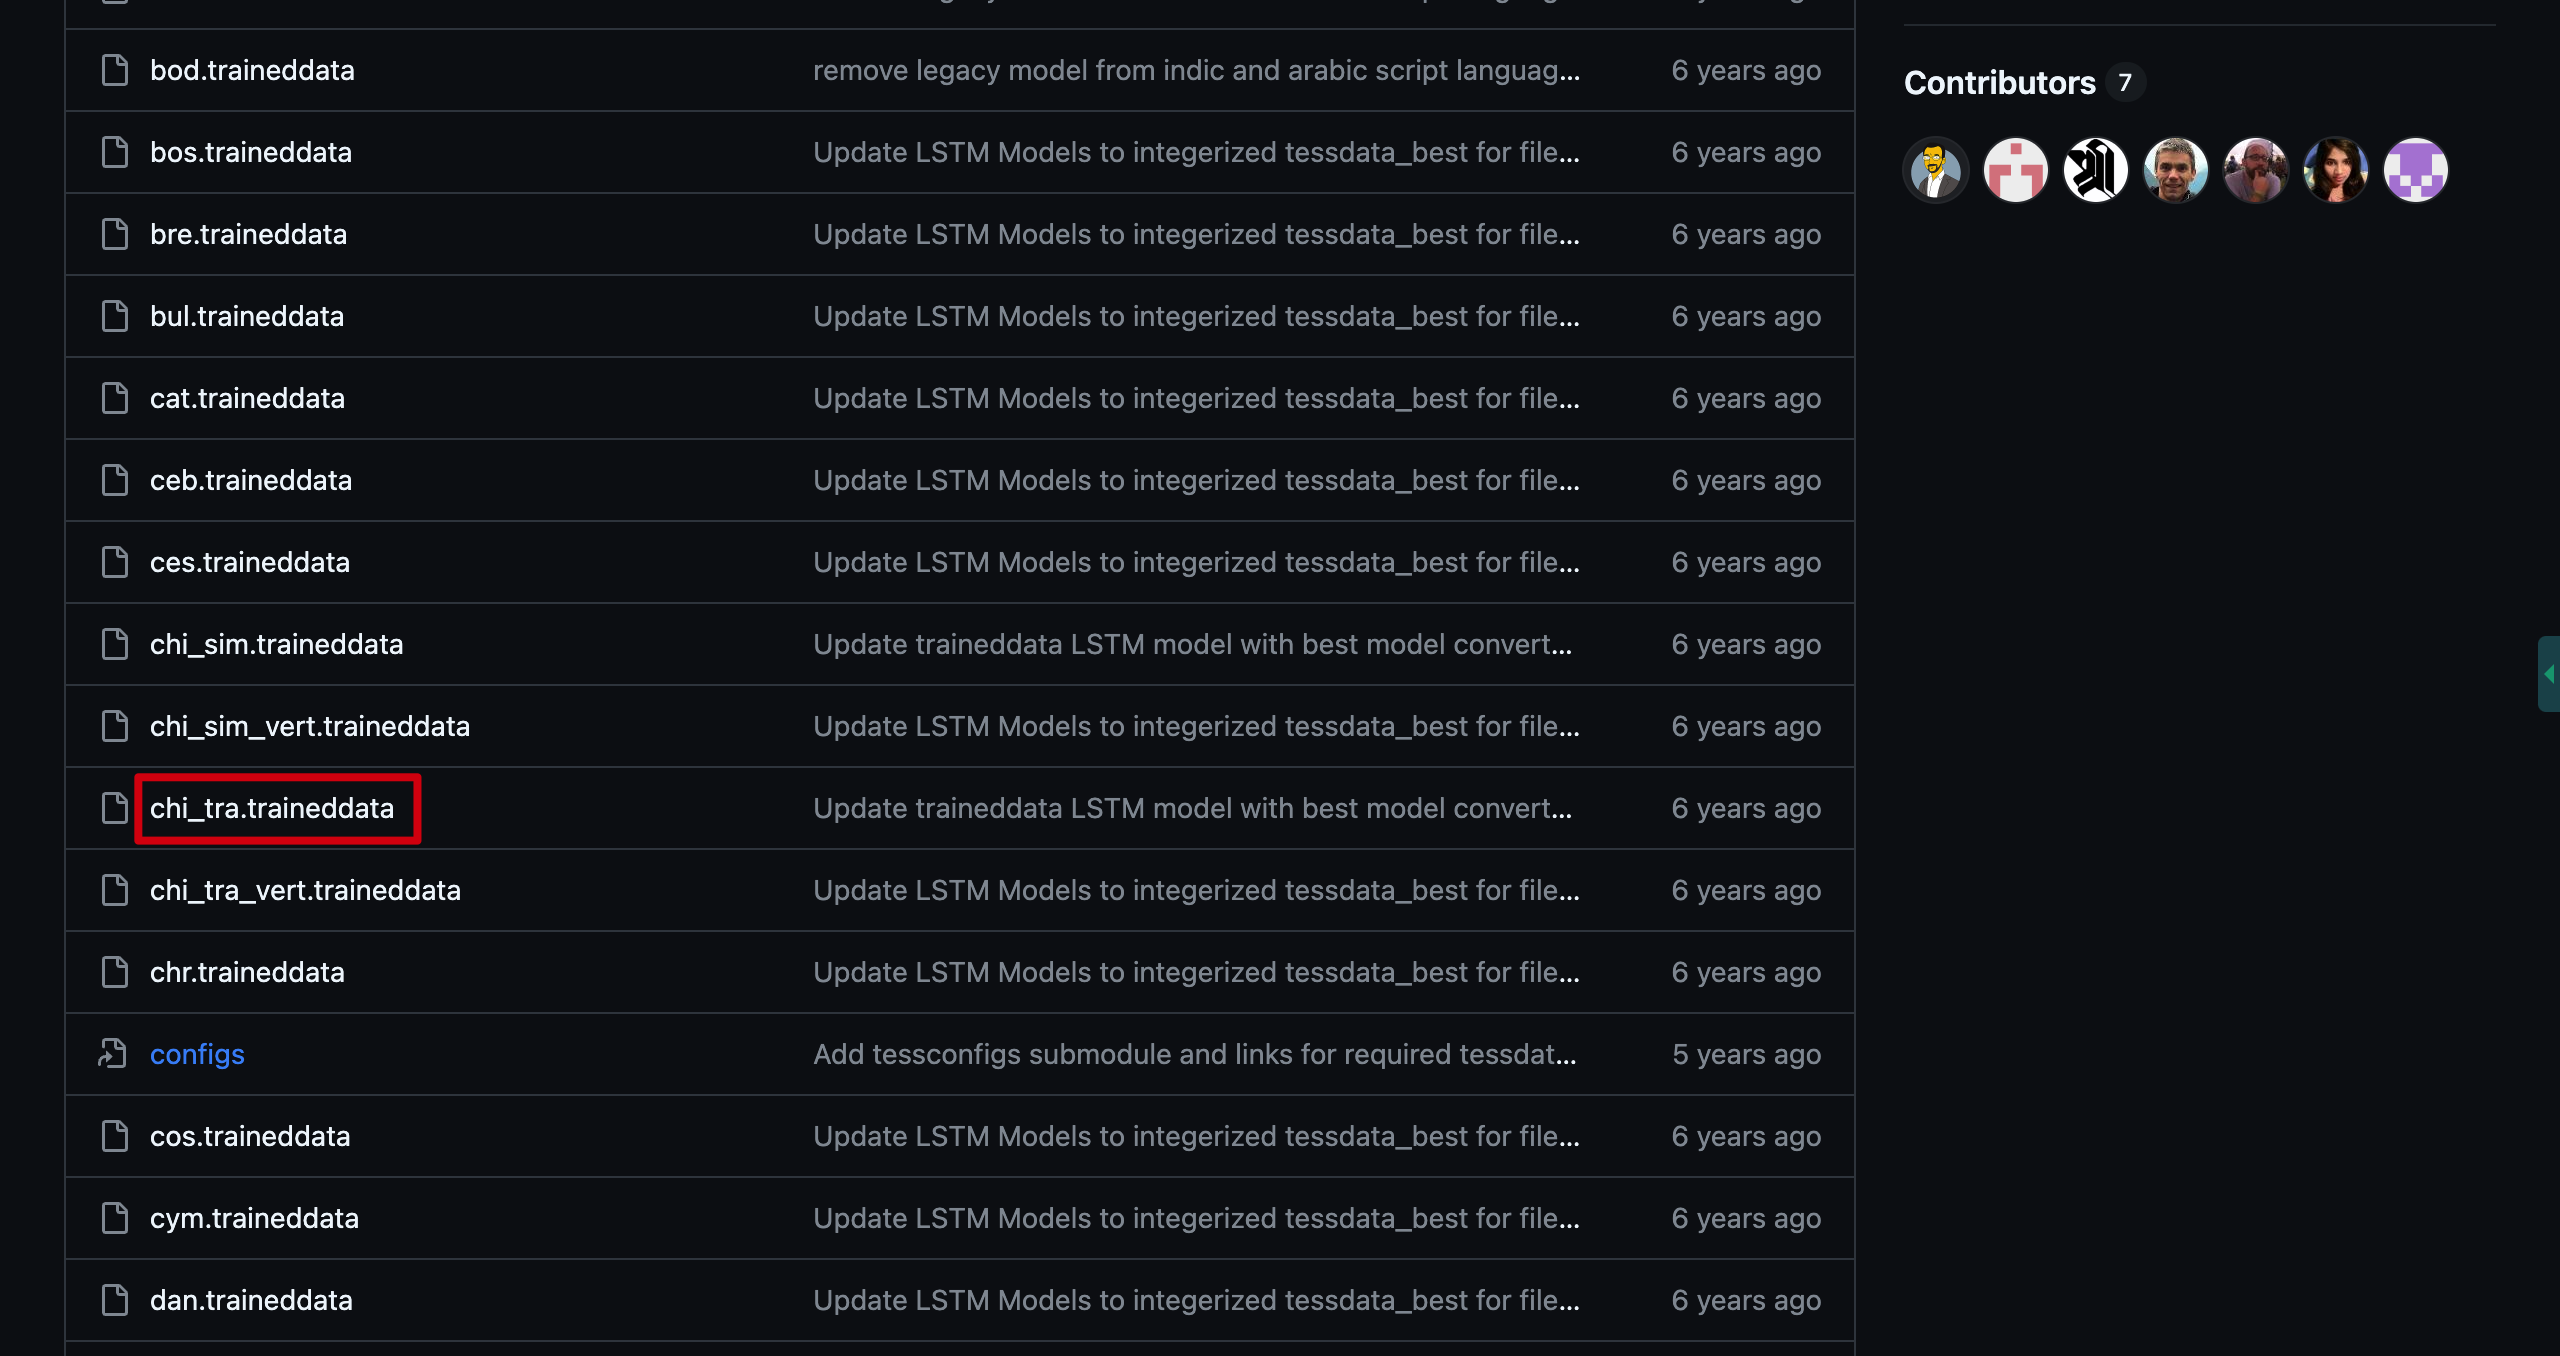

In [ ]:
# Install Tesseract and the necessary libraries
!apt-get install tesseract-ocr
!pip install pytesseract Pillow

import pytesseract
from PIL import Image
import os

print("Upload the language package：")
from google.colab import files
uploaded = files.upload()


!mkdir -p /usr/share/tesseract-ocr/4.00/tessdata/

# 将上传的文件复制到目录
!cp chi_tra.traineddata /usr/share/tesseract-ocr/4.00/tessdata/


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
Upload the language package：


KeyboardInterrupt: 

In [ ]:
# 检查语言包已经安装在指定目录下
!ls /usr/share/tesseract-ocr/4.00/tessdata/

chi_tra.traineddata  configs  eng.traineddata  osd.traineddata	pdf.ttf  tessconfigs




---


1.2 Prepare a screenshot with Cantonese characters(such as Xiaohongshu), replace the image path.

1.2 准备一张带粤语口语文字的图片（比如，小红书），然后替换掉代码中的图片路径。

In [ ]:
import os
os.environ['TESSDATA_PREFIX'] = '/usr/share/tesseract-ocr/4.00/tessdata/'

# Update this path to the Tesseract executable
pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'

# 上传要识别的图片文件
# print("Please upload image.")
# from google.colab import files
# image= files.upload()

# Load the image from file
# Make sure to upload the image to the Colab environment first
image_path = '/content/sample_data/IMG_2548.PNG'

# Check if the image file exists
if not os.path.isfile(image_path):
    print(f"Error: The file at {image_path} does not exist.")
else:
    # Open the image file
    try:
        image = Image.open(image_path)

        # Use pytesseract to do OCR on the image
        text = pytesseract.image_to_string(image, lang='chi_tra')

        # Print the detected text
        print("Detected text:")
        print(text)
    except Exception as e:
        print(f"An error occurred while processing the image: {e}")

Detected text:
你 班 友 仔 , 自 己 老 豆 老母 生 日 都 無 咁 重視 啊



# 2 To translate the Cantonese spoken language to Mandarin using Code from @AlienKevin
(link
:https://github.com/AlienKevin/phrase-based-canto-mando)

2.1 Download  ***common_trad_chars.txt***
 & ***can2man_phrase_table.txt***  from github and upload to the execution path.

2.1 下载两个txt文件  ***common_trad_chars.txt***  & ***can2man_phrase_table.txt***  并上传到运行路径下。
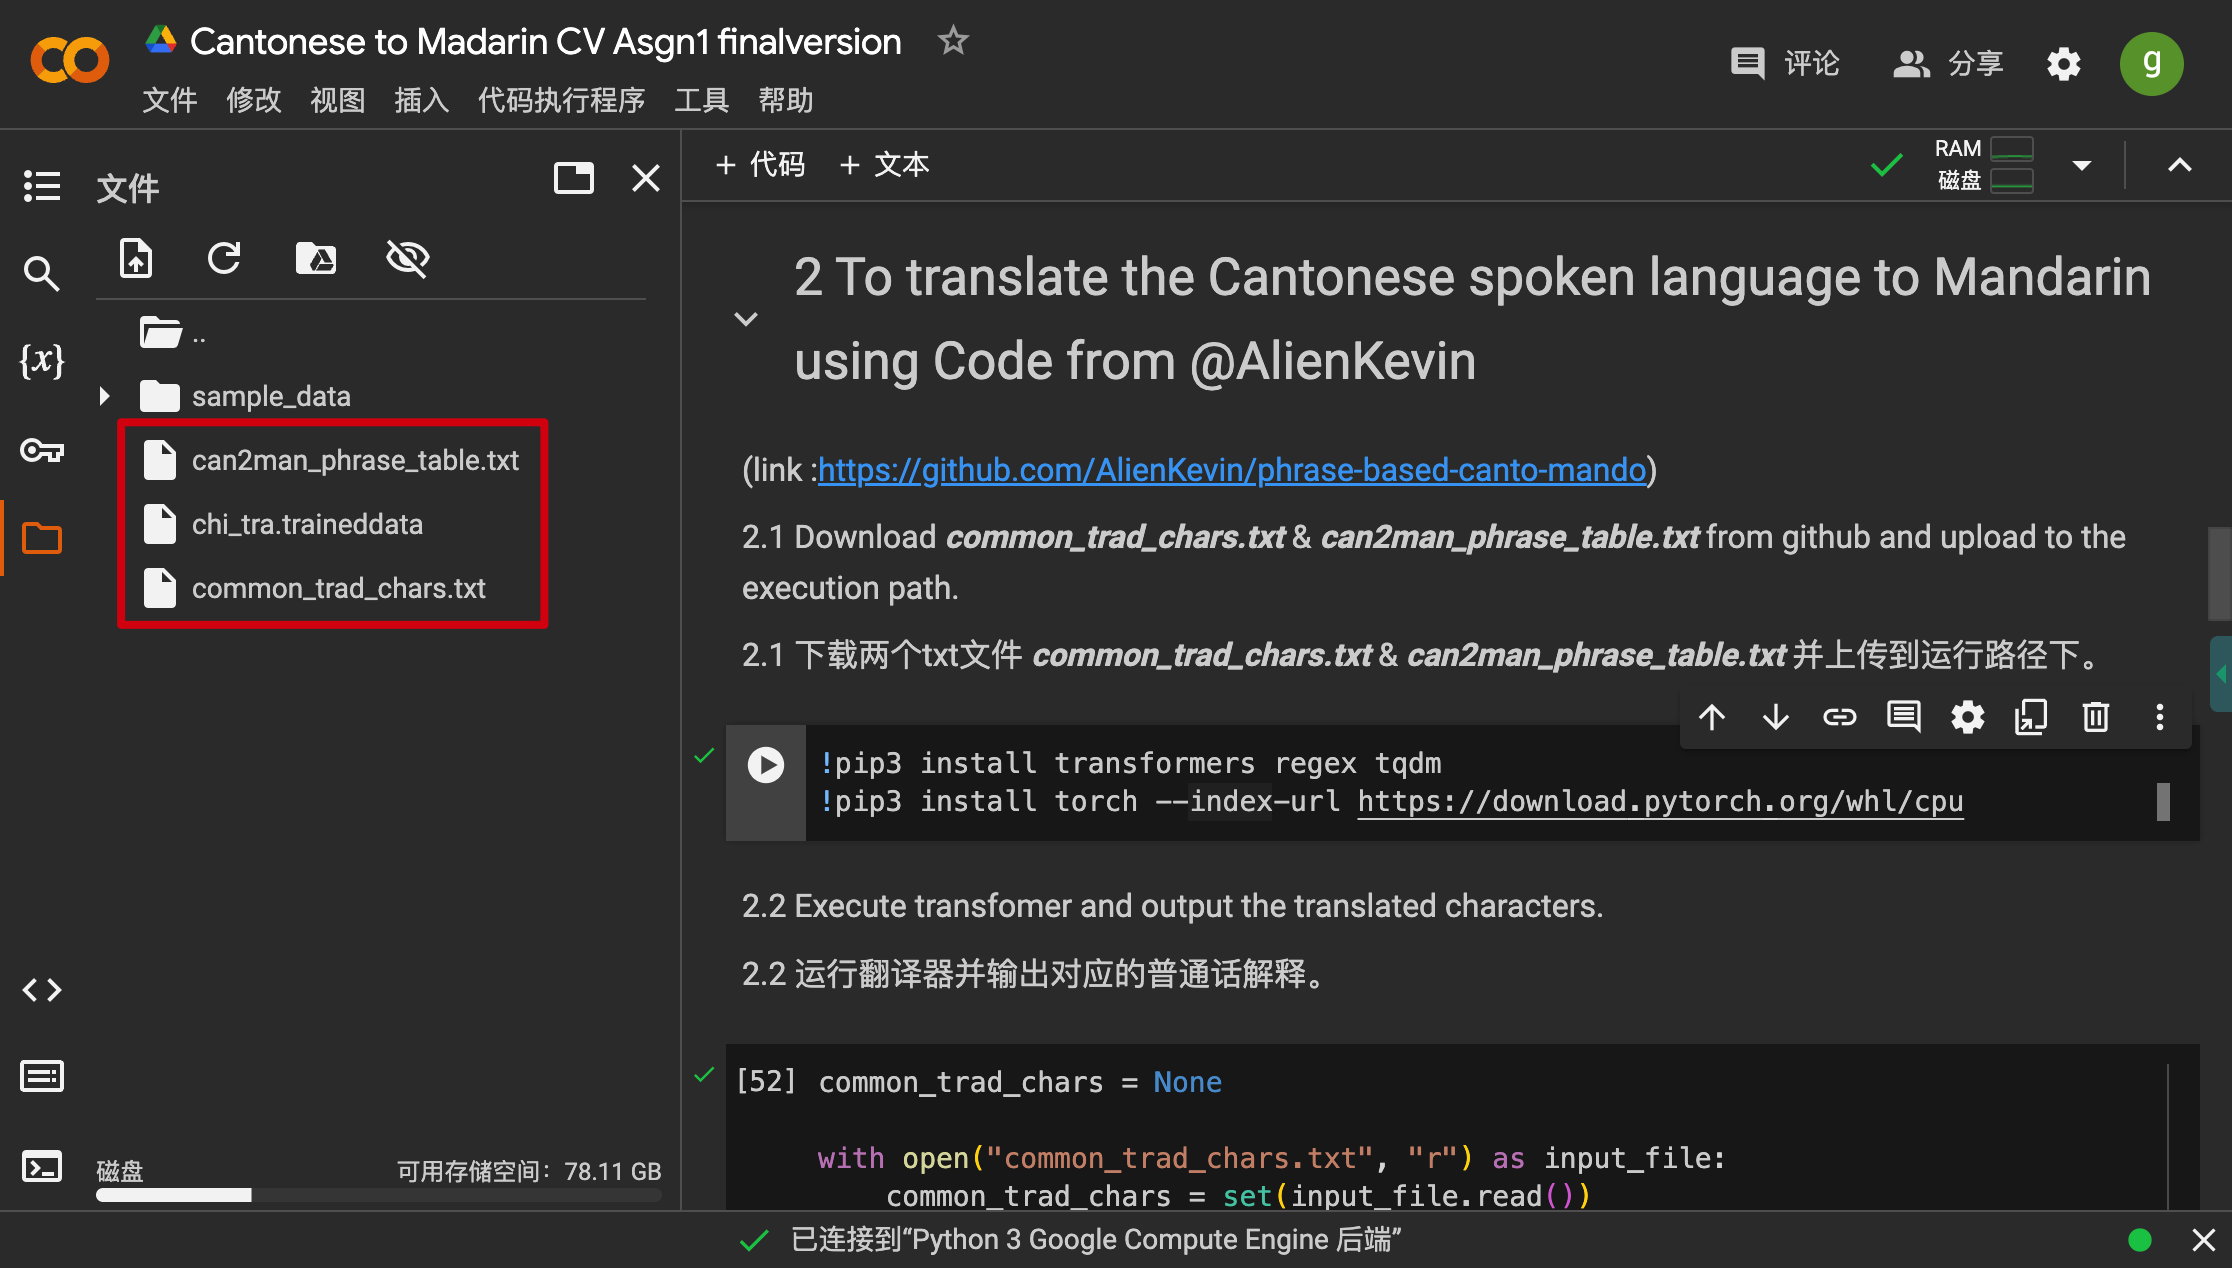

In [ ]:
!pip3 install transformers regex tqdm
!pip3 install torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu




---


2.2 Execute transfomer and output the translated characters.

2.2 运行翻译器并输出对应的普通话解释。

In [ ]:
common_trad_chars = None

with open("common_trad_chars.txt", "r") as input_file:
    common_trad_chars = set(input_file.read())

print("A sample of common traditional characters: ", list(common_trad_chars)[0:10])

from collections import defaultdict

can2man_table = defaultdict(list)

with open("can2man_phrase_table.txt", "r") as input_file:
  for line in input_file.read().splitlines():
    [can, man] = line.split("|")
    can2man_table[can].append(man)

def longest_match_translate(s, phrase_table):
    man_phrases: list[list[str]] = []
    oov_word = ""
    while s:
        longest_match = None
        for phrase in phrase_table:
            if s.startswith(phrase) and (longest_match is None or len(phrase) > len(longest_match)):
                longest_match = phrase
        if longest_match:
            if len(oov_word) > 0:
                man_phrases.append([oov_word])
                oov_word = ""
            can_original = [longest_match] if len(longest_match) <= 1 and all(c in common_trad_chars for c in longest_match) else []
            man_phrase = phrase_table[longest_match]
            man_phrases.append(can_original + man_phrase)
            s = s[len(longest_match):].lstrip()
        else:
            oov_word += s[0]
            s = s[1:].lstrip()
    if len(oov_word) > 0:
        man_phrases.append([oov_word])
    # Merge anchor phrases (those with a single mandarin translation)
    i = 0
    merged_man_phrases = []
    while i < len(man_phrases):
        merged_phrase = ""
        while i < len(man_phrases) and len(man_phrases[i]) == 1:
            merged_phrase += man_phrases[i][0]
            i += 1
        if len(merged_phrase) > 0:
            merged_man_phrases.append([merged_phrase])
            merged_phrase = ""
        else:
            merged_man_phrases.append(man_phrases[i])
            i += 1
    return merged_man_phrases

from transformers import BertTokenizerFast, GPT2LMHeadModel
tokenizer = BertTokenizerFast.from_pretrained('bert-base-chinese')
model = GPT2LMHeadModel.from_pretrained('ckiplab/gpt2-base-chinese')

import torch

def get_most_fluent_sentence_index(candidates):
    encodings = [tokenizer(candidate, return_tensors="pt") for candidate in candidates]
    ppls = []
    for encoding in encodings:
        target_ids_list = []
        seq_len = encoding.input_ids.size(1)
        for end_loc in range(2, seq_len + 1, 2):
            target_ids = encoding.input_ids[0].clone()
            target_ids[end_loc:] = -100
            target_ids_list.append(target_ids)
        target_ids = torch.stack(target_ids_list)
        input_ids = encoding.input_ids.expand(target_ids.shape)
        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            ppl = outputs.loss.item() * seq_len
            ppls.append(ppl)
    return torch.argmin(torch.tensor(ppls))

import regex

# match any unicode punctuation character and anything after it
punctuation_pattern = regex.compile(r"\p{P}+.*", flags=regex.UNICODE)
chinese_char_pattern = regex.compile(r"[\u4e00-\u9fff]")

def chop_off_at_punctuation(s: str) -> str:
    match = punctuation_pattern.search(s)
    if match:
        index = match.start()
        return s[:index]
    else:
        return s

def chop_off_at_canto_char(s: str) -> str:
    for i, c in enumerate(s):
        if chinese_char_pattern.match(c) and not c in common_trad_chars:
            return s[:i]
    return s

def flatten(l):
    return [item for sublist in l for item in sublist]

def can2man(s: str) -> str:
    s = s.replace(" ", "")
    man_phrases = longest_match_translate(s, can2man_table)
    # print(man_phrases)
    for i, phrases in enumerate(man_phrases):
        if len(phrases) == 1:
            continue
        else:
            j = i + 1
            while j < len(man_phrases) and man_phrases[j] == 1:
                j += 1
            backward_context = "".join(flatten(man_phrases[max(0, i - 10):i]))
            forward_context = "".join(flatten(man_phrases[i + 1:j]))
            # forward context is too small
            while len(forward_context) < 10 and j < len(man_phrases):
                forward_context += man_phrases[j][0]
                j += 1
            forward_context = chop_off_at_canto_char(chop_off_at_punctuation(forward_context))
            # print(f"i={i} backward_context={backward_context}, forward_context={forward_context}")
            candidates = [backward_context + phrase + forward_context for phrase in man_phrases[i]]
            j = get_most_fluent_sentence_index(candidates)
            man_phrases[i] = [man_phrases[i][j]]
    # print(man_phrases)
    return "".join(flatten(man_phrases))

assert can2man("唔該你細聲啲，我喺度做緊嘢。") == "請你小聲點，我在這裡正在做東西。"

from tqdm import tqdm
import sys

with open("/content/can-input.txt", "w", encoding="utf-8") as file:
    file.write(text)

print("字符串已成功写入 can-input.txt")

i = sys.argv[1]

with open("/content/can-input.txt", "r") as input_file, open("/content/man-output", "w+") as output_file:
    print("Translating can-input.txt and saving results to man-output")
    for line in tqdm(input_file.read().splitlines()):
        output_file.write(can2man(line) + "\n")

with open("/content/man-output", "r", encoding="utf-8") as file:
    content = file.read()
    print("Result:\n", content)


A sample of common traditional characters:  ['寓', '或', '杭', '甯', '覓', '雄', '耘', '風', '潰', '嵌']
字符串已成功写入 can-input.txt
Translating can-input.txt and saving results to man-output


100%|██████████| 2/2 [00:09<00:00,  4.82s/it]

Result:
 你們這群家伙,自己爹媽生日都無般重視啊


